<a href="https://colab.research.google.com/github/brbvisayas/folds/blob/main/AlphaFold2_top1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/sokrypton/ColabFold/main/.github/ColabFold_Marv_Logo_Small.png" height="200" align="right" style="height:240px">

##ColabFold v1.5.5: AlphaFold2 using MMseqs2

Easy to use protein structure and complex prediction using [AlphaFold2](https://www.nature.com/articles/s41586-021-03819-2) and [Alphafold2-multimer](https://www.biorxiv.org/content/10.1101/2021.10.04.463034v1). Sequence alignments/templates are generated through [MMseqs2](mmseqs.com) and [HHsearch](https://github.com/soedinglab/hh-suite). For more details, see <a href="#Instructions">bottom</a> of the notebook, checkout the [ColabFold GitHub](https://github.com/sokrypton/ColabFold) and [Nature Protocols](https://www.nature.com/articles/s41596-024-01060-5).

Old versions: [v1.4](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.4.0/AlphaFold2.ipynb), [v1.5.1](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.5.1/AlphaFold2.ipynb), [v1.5.2](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.5.2/AlphaFold2.ipynb), [v1.5.3-patch](https://colab.research.google.com/github/sokrypton/ColabFold/blob/56c72044c7d51a311ca99b953a71e552fdc042e1/AlphaFold2.ipynb)

[Mirdita M, Schütze K, Moriwaki Y, Heo L, Ovchinnikov S, Steinegger M. ColabFold: Making protein folding accessible to all.
*Nature Methods*, 2022](https://www.nature.com/articles/s41592-022-01488-1)

In [1]:
#@title Input protein sequence(s), then hit `Runtime` -> `Run all`
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = 'QVQLQESGGGLVQAGGSLRLSCAASGNIFASTDMGWYRQAPGKERELVAAISRGASTNYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAVDSYSGVDGIFGPQLAYWGQGTQVTVSS' #@param {type:"string"}
#@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
jobname = 'top1' #@param {type:"string"}
# number of models to use
num_relax = 5 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "pdb100" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))

jobname top1_b6a81
sequence QVQLQESGGGLVQAGGSLRLSCAASGNIFASTDMGWYRQAPGKERELVAAISRGASTNYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAVDSYSGVDGIFGPQLAYWGQGTQVTVSS
length 124


In [2]:
#@title Install dependencies
%%time
import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  # hack to fix TF crash
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

installing colabfold...
installing conda...
installing hhsuite and amber...
CPU times: user 6.13 ms, sys: 2.42 ms, total: 8.55 ms
Wall time: 1min 28s


In [3]:
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

In [4]:
#@markdown ### Advanced settings
model_type = "deepfold_v1" #@param ["auto", "alphafold2_ptm", "alphafold2_multimer_v1", "alphafold2_multimer_v2", "alphafold2_multimer_v3", "deepfold_v1", "alphafold2"]
#@markdown - if `auto` selected, will use `alphafold2_ptm` for monomer prediction and `alphafold2_multimer_v3` for complex prediction.
#@markdown Any of the mode_types can be used (regardless if input is monomer or complex).
num_recycles = "6" #@param ["auto", "0", "1", "3", "6", "12", "24", "48"]
#@markdown - if `auto` selected, will use `num_recycles=20` if `model_type=alphafold2_multimer_v3`, else `num_recycles=3` .
recycle_early_stop_tolerance = "auto" #@param ["auto", "0.0", "0.5", "1.0"]
#@markdown - if `auto` selected, will use `tol=0.5` if `model_type=alphafold2_multimer_v3` else `tol=0.0`.
relax_max_iterations = 2000 #@param [0, 200, 2000] {type:"raw"}
#@markdown - max amber relax iterations, `0` = unlimited (AlphaFold2 default, can take very long)
pairing_strategy = "greedy" #@param ["greedy", "complete"] {type:"string"}
#@markdown - `greedy` = pair any taxonomically matching subsets, `complete` = all sequences have to match in one line.
calc_extra_ptm = True #@param {type:"boolean"}
#@markdown - return pairwise chain iptm/actifptm

#@markdown #### Sample settings
#@markdown -  enable dropouts and increase number of seeds to sample predictions from uncertainty of the model.
#@markdown -  decrease `max_msa` to increase uncertainity
max_msa = "auto" #@param ["auto", "512:1024", "256:512", "64:128", "32:64", "16:32"]
num_seeds = 4 #@param [1,2,4,8,16] {type:"raw"}
use_dropout = True #@param {type:"boolean"}

num_recycles = None if num_recycles == "auto" else int(num_recycles)
recycle_early_stop_tolerance = None if recycle_early_stop_tolerance == "auto" else float(recycle_early_stop_tolerance)
if max_msa == "auto": max_msa = None

#@markdown #### Save settings
save_all = False #@param {type:"boolean"}
save_recycles = False #@param {type:"boolean"}
save_to_google_drive = False #@param {type:"boolean"}
#@markdown -  if the save_to_google_drive option was selected, the result zip will be uploaded to your Google Drive
dpi = 200 #@param {type:"integer"}
#@markdown - set dpi for image resolution

if save_to_google_drive:
  from pydrive2.drive import GoogleDrive
  from pydrive2.auth import GoogleAuth
  from google.colab import auth
  from oauth2client.client import GoogleCredentials
  auth.authenticate_user()
  gauth = GoogleAuth()
  gauth.credentials = GoogleCredentials.get_application_default()
  drive = GoogleDrive(gauth)
  print("You are logged into Google Drive and are good to go!")

#@markdown Don't forget to hit `Runtime` -> `Run all` after updating the form.

2026-03-06 12:32:20,553 Running on GPU
2026-03-06 12:32:21,050 Calculating extra pTM is not supported for single chain prediction, skipping it.
2026-03-06 12:32:21,054 Found 9 citations for tools or databases
2026-03-06 12:32:21,055 Query 1/1: top1_b6a81 (length 124)


PENDING:   0%|          | 0/150 [elapsed: 00:00 remaining: ?]

2026-03-06 12:32:21,593 Sleeping for 9s. Reason: PENDING


PENDING:   0%|          | 0/150 [elapsed: 00:10 remaining: ?]

2026-03-06 12:32:31,069 Sleeping for 6s. Reason: PENDING


...

2026-03-06 12:33:18,228 Sleeping for 9s. Reason: RUNNING


RUNNING:  25%|██▌       | 38/150 [elapsed: 01:06 remaining: 02:31]

2026-03-06 12:33:27,727 Sleeping for 5s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 01:13 remaining: 00:00]


2026-03-06 12:33:51,442 Sequence 0 found templates: ['7kn6_C', '7lx5_A', '7b17_B', '4tsb_H', '4tsa_H', '7rth_H', '6qx4_H', '7b3o_H', '4tsc_H', '7np1_I', '7np1_J', '7n3g_H', '7b17_B', '7np1_H', '7czq_J', '7n3i_H', '7pqy_B', '7e3o_H', '7q0g_H', '7e7y_C']


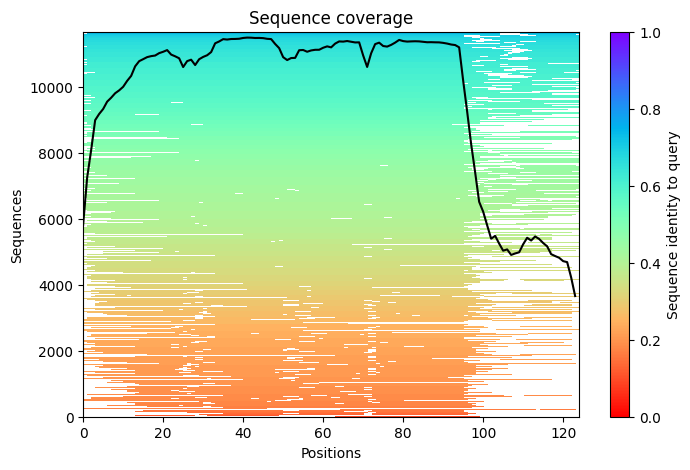

2026-03-06 12:33:53,312 Setting max_seq=512, max_extra_seq=5120
2026-03-06 12:34:55,199 deepfold_v1_model_1_seed_000 recycle=0 pLDDT=88.8
2026-03-06 12:35:35,649 deepfold_v1_model_1_seed_000 recycle=1 pLDDT=88.5 tol=0.236
2026-03-06 12:35:43,958 deepfold_v1_model_1_seed_000 recycle=2 pLDDT=88.8 tol=0.294
2026-03-06 12:35:52,387 deepfold_v1_model_1_seed_000 recycle=3 pLDDT=89.2 tol=0.441
2026-03-06 12:36:00,947 deepfold_v1_model_1_seed_000 recycle=4 pLDDT=89.1 tol=0.303
2026-03-06 12:36:09,618 deepfold_v1_model_1_seed_000 recycle=5 pLDDT=88.9 tol=0.204
2026-03-06 12:36:18,417 deepfold_v1_model_1_seed_000 recycle=6 pLDDT=89 tol=0.194
2026-03-06 12:36:18,418 deepfold_v1_model_1_seed_000 took 126.6s (6 recycles)


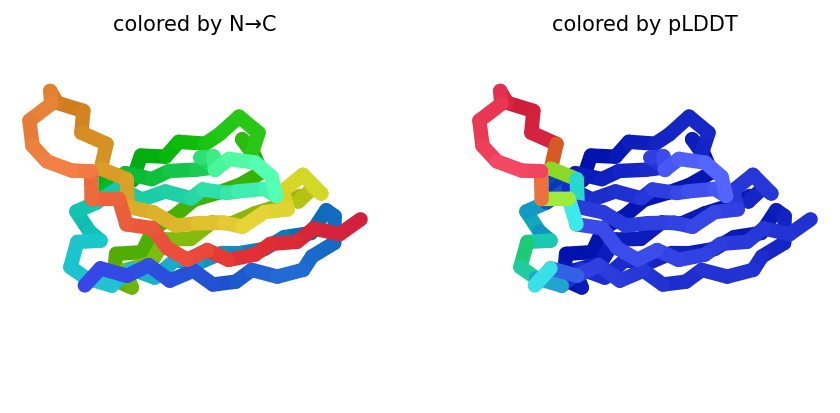

2026-03-06 12:36:27,471 deepfold_v1_model_2_seed_000 recycle=0 pLDDT=87.5
2026-03-06 12:36:36,498 deepfold_v1_model_2_seed_000 recycle=1 pLDDT=87.2 tol=0.232
2026-03-06 12:36:45,674 deepfold_v1_model_2_seed_000 recycle=2 pLDDT=87.5 tol=0.254
2026-03-06 12:36:54,905 deepfold_v1_model_2_seed_000 recycle=3 pLDDT=87.9 tol=0.286
2026-03-06 12:37:04,128 deepfold_v1_model_2_seed_000 recycle=4 pLDDT=87.9 tol=0.267
2026-03-06 12:37:13,376 deepfold_v1_model_2_seed_000 recycle=5 pLDDT=87.7 tol=0.141
2026-03-06 12:37:22,563 deepfold_v1_model_2_seed_000 recycle=6 pLDDT=87.8 tol=0.154
2026-03-06 12:37:22,564 deepfold_v1_model_2_seed_000 took 64.0s (6 recycles)


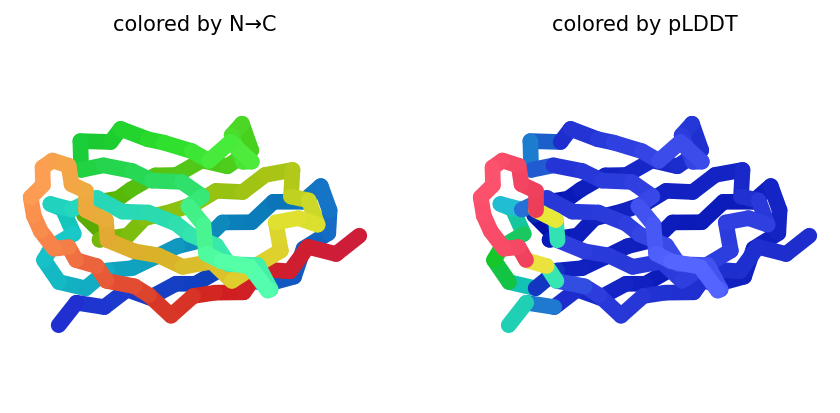

2026-03-06 12:37:53,091 deepfold_v1_model_3_seed_000 recycle=0 pLDDT=86.9
2026-03-06 12:38:21,672 deepfold_v1_model_3_seed_000 recycle=1 pLDDT=87.2 tol=0.866
2026-03-06 12:38:30,773 deepfold_v1_model_3_seed_000 recycle=2 pLDDT=87.4 tol=0.211
2026-03-06 12:38:39,924 deepfold_v1_model_3_seed_000 recycle=3 pLDDT=87.7 tol=0.407
2026-03-06 12:38:49,176 deepfold_v1_model_3_seed_000 recycle=4 pLDDT=87.6 tol=0.239
2026-03-06 12:38:58,475 deepfold_v1_model_3_seed_000 recycle=5 pLDDT=87.6 tol=0.184
2026-03-06 12:39:07,653 deepfold_v1_model_3_seed_000 recycle=6 pLDDT=87.6 tol=0.159
2026-03-06 12:39:07,653 deepfold_v1_model_3_seed_000 took 105.0s (6 recycles)


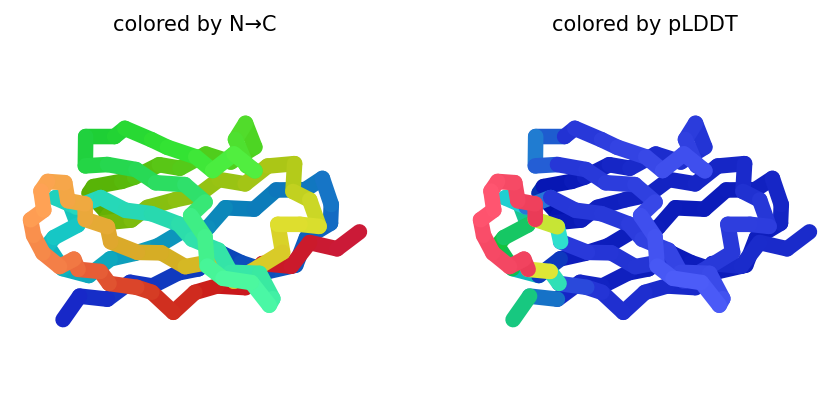

2026-03-06 12:39:16,921 deepfold_v1_model_4_seed_000 recycle=0 pLDDT=86.3
2026-03-06 12:39:25,964 deepfold_v1_model_4_seed_000 recycle=1 pLDDT=86.9 tol=0.76
2026-03-06 12:39:35,001 deepfold_v1_model_4_seed_000 recycle=2 pLDDT=87 tol=0.156
2026-03-06 12:39:44,078 deepfold_v1_model_4_seed_000 recycle=3 pLDDT=87.2 tol=0.315
2026-03-06 12:39:53,213 deepfold_v1_model_4_seed_000 recycle=4 pLDDT=86.9 tol=0.282
2026-03-06 12:40:02,381 deepfold_v1_model_4_seed_000 recycle=5 pLDDT=86.8 tol=0.25
2026-03-06 12:40:11,549 deepfold_v1_model_4_seed_000 recycle=6 pLDDT=86.9 tol=0.131
2026-03-06 12:40:11,550 deepfold_v1_model_4_seed_000 took 63.8s (6 recycles)


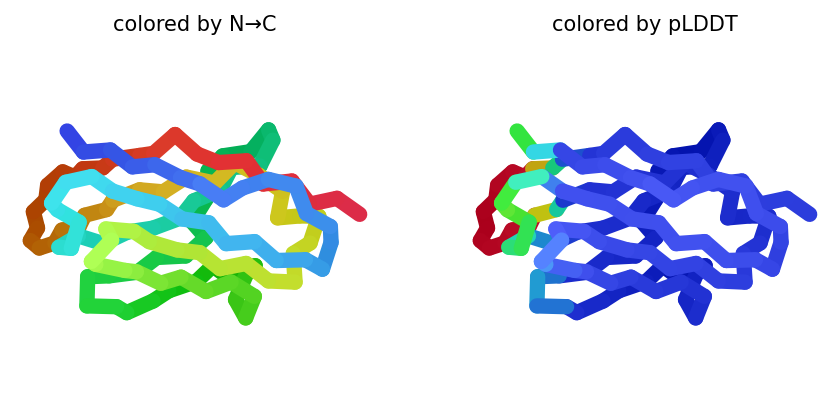

2026-03-06 12:40:20,792 deepfold_v1_model_5_seed_000 recycle=0 pLDDT=86.8
2026-03-06 12:40:29,939 deepfold_v1_model_5_seed_000 recycle=1 pLDDT=86.8 tol=0.794
2026-03-06 12:40:39,063 deepfold_v1_model_5_seed_000 recycle=2 pLDDT=86.9 tol=0.188
2026-03-06 12:40:48,185 deepfold_v1_model_5_seed_000 recycle=3 pLDDT=87.2 tol=0.325
2026-03-06 12:40:57,320 deepfold_v1_model_5_seed_000 recycle=4 pLDDT=87 tol=0.233
2026-03-06 12:41:06,481 deepfold_v1_model_5_seed_000 recycle=5 pLDDT=86.8 tol=0.672
2026-03-06 12:41:15,649 deepfold_v1_model_5_seed_000 recycle=6 pLDDT=86.8 tol=0.565
2026-03-06 12:41:15,650 deepfold_v1_model_5_seed_000 took 64.0s (6 recycles)


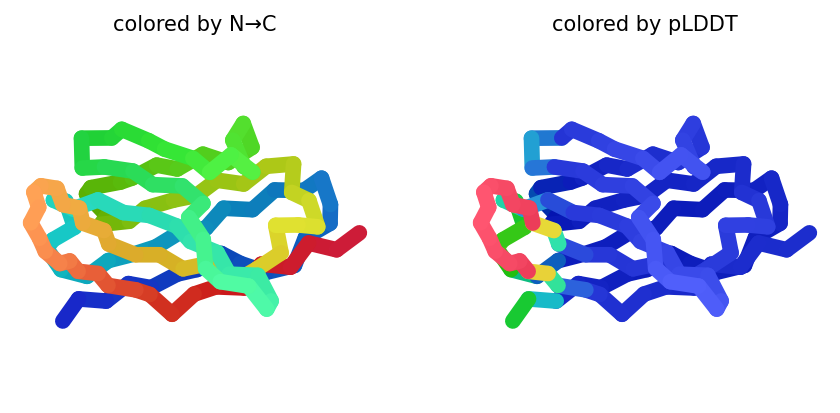

2026-03-06 12:41:32,125 deepfold_v1_model_1_seed_001 recycle=0 pLDDT=87.9
2026-03-06 12:41:41,355 deepfold_v1_model_1_seed_001 recycle=1 pLDDT=88.4 tol=1.76
2026-03-06 12:41:50,593 deepfold_v1_model_1_seed_001 recycle=2 pLDDT=88.5 tol=0.486
2026-03-06 12:41:59,830 deepfold_v1_model_1_seed_001 recycle=3 pLDDT=88.8 tol=0.384
2026-03-06 12:42:08,972 deepfold_v1_model_1_seed_001 recycle=4 pLDDT=88.8 tol=0.313
2026-03-06 12:42:18,034 deepfold_v1_model_1_seed_001 recycle=5 pLDDT=88.8 tol=0.433
2026-03-06 12:42:27,071 deepfold_v1_model_1_seed_001 recycle=6 pLDDT=89 tol=0.321
2026-03-06 12:42:27,072 deepfold_v1_model_1_seed_001 took 64.1s (6 recycles)


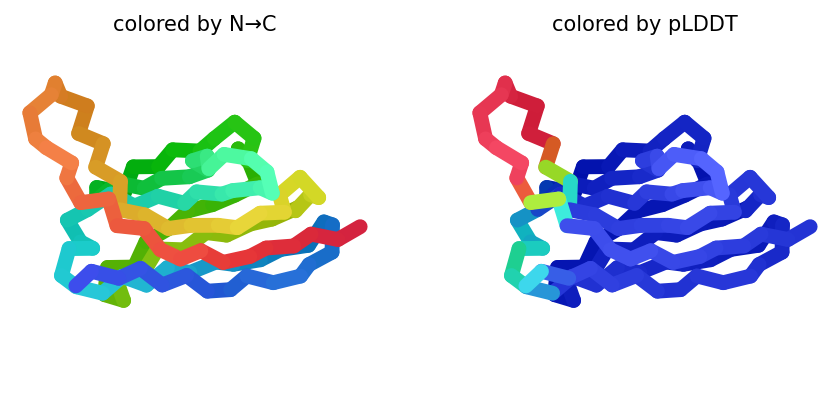

2026-03-06 12:42:36,192 deepfold_v1_model_2_seed_001 recycle=0 pLDDT=86.6
2026-03-06 12:42:45,293 deepfold_v1_model_2_seed_001 recycle=1 pLDDT=87.2 tol=1.22
2026-03-06 12:42:54,502 deepfold_v1_model_2_seed_001 recycle=2 pLDDT=87.2 tol=0.332
2026-03-06 12:43:03,735 deepfold_v1_model_2_seed_001 recycle=3 pLDDT=87.5 tol=0.254
2026-03-06 12:43:12,947 deepfold_v1_model_2_seed_001 recycle=4 pLDDT=87.4 tol=0.281
2026-03-06 12:43:22,059 deepfold_v1_model_2_seed_001 recycle=5 pLDDT=87.5 tol=0.341
2026-03-06 12:43:31,163 deepfold_v1_model_2_seed_001 recycle=6 pLDDT=87.7 tol=0.18
2026-03-06 12:43:31,163 deepfold_v1_model_2_seed_001 took 64.0s (6 recycles)


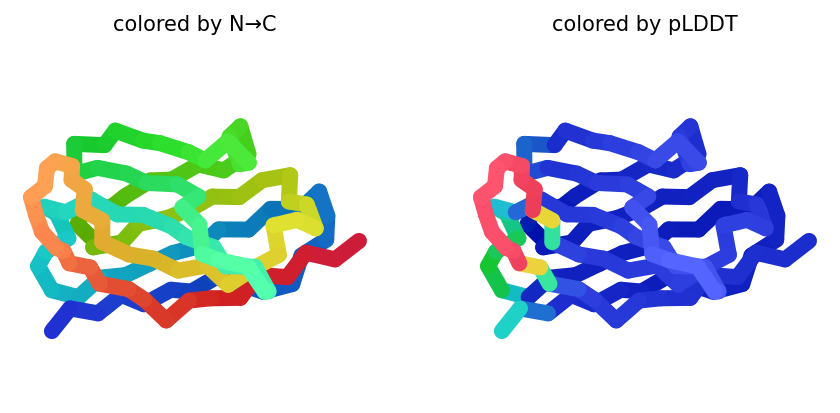

2026-03-06 12:43:40,449 deepfold_v1_model_3_seed_001 recycle=0 pLDDT=86.2
2026-03-06 12:43:49,583 deepfold_v1_model_3_seed_001 recycle=1 pLDDT=87.7 tol=0.765
2026-03-06 12:43:58,720 deepfold_v1_model_3_seed_001 recycle=2 pLDDT=87.4 tol=0.408
2026-03-06 12:44:07,867 deepfold_v1_model_3_seed_001 recycle=3 pLDDT=87.6 tol=0.186
2026-03-06 12:44:17,017 deepfold_v1_model_3_seed_001 recycle=4 pLDDT=87.3 tol=0.295
2026-03-06 12:44:26,161 deepfold_v1_model_3_seed_001 recycle=5 pLDDT=87.4 tol=0.435
2026-03-06 12:44:35,315 deepfold_v1_model_3_seed_001 recycle=6 pLDDT=87.5 tol=0.155
2026-03-06 12:44:35,316 deepfold_v1_model_3_seed_001 took 64.0s (6 recycles)


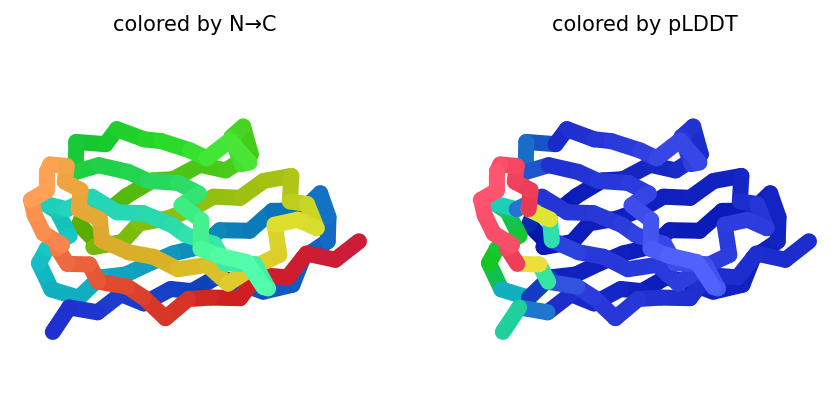

2026-03-06 12:44:44,572 deepfold_v1_model_4_seed_001 recycle=0 pLDDT=85.9
2026-03-06 12:44:53,703 deepfold_v1_model_4_seed_001 recycle=1 pLDDT=86.9 tol=0.5
2026-03-06 12:45:02,837 deepfold_v1_model_4_seed_001 recycle=2 pLDDT=86.8 tol=0.285
2026-03-06 12:45:11,978 deepfold_v1_model_4_seed_001 recycle=3 pLDDT=86.8 tol=0.197
2026-03-06 12:45:21,122 deepfold_v1_model_4_seed_001 recycle=4 pLDDT=86.6 tol=0.295
2026-03-06 12:45:30,252 deepfold_v1_model_4_seed_001 recycle=5 pLDDT=86.4 tol=0.442
2026-03-06 12:45:39,405 deepfold_v1_model_4_seed_001 recycle=6 pLDDT=86.8 tol=0.169
2026-03-06 12:45:39,406 deepfold_v1_model_4_seed_001 took 64.0s (6 recycles)


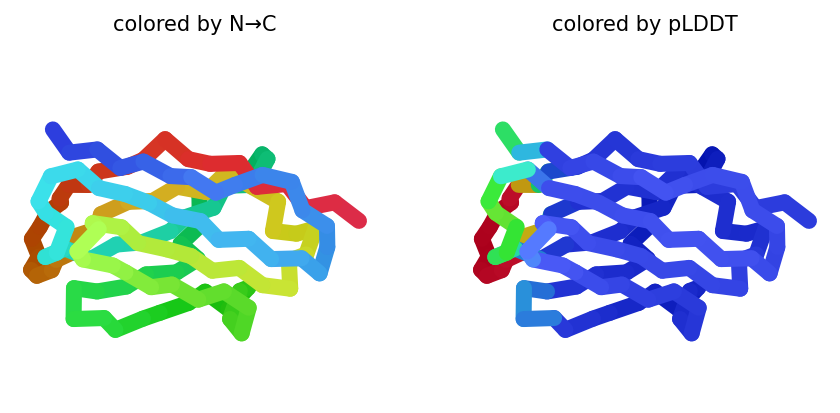

2026-03-06 12:45:48,641 deepfold_v1_model_5_seed_001 recycle=0 pLDDT=85.6
2026-03-06 12:45:57,770 deepfold_v1_model_5_seed_001 recycle=1 pLDDT=86.9 tol=0.302
2026-03-06 12:46:06,898 deepfold_v1_model_5_seed_001 recycle=2 pLDDT=86.7 tol=0.506
2026-03-06 12:46:16,029 deepfold_v1_model_5_seed_001 recycle=3 pLDDT=86.9 tol=0.252
2026-03-06 12:46:25,172 deepfold_v1_model_5_seed_001 recycle=4 pLDDT=86.4 tol=0.334
2026-03-06 12:46:34,306 deepfold_v1_model_5_seed_001 recycle=5 pLDDT=86.5 tol=0.495
2026-03-06 12:46:43,455 deepfold_v1_model_5_seed_001 recycle=6 pLDDT=86.6 tol=0.175
2026-03-06 12:46:43,456 deepfold_v1_model_5_seed_001 took 64.0s (6 recycles)


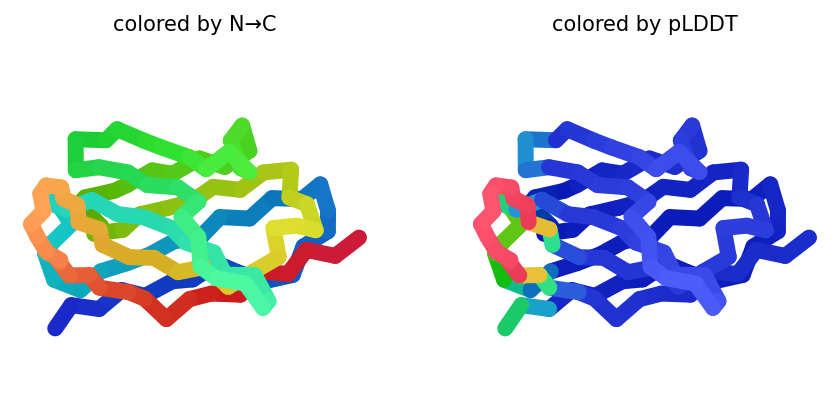

2026-03-06 12:46:59,609 deepfold_v1_model_1_seed_002 recycle=0 pLDDT=88.2
2026-03-06 12:47:08,796 deepfold_v1_model_1_seed_002 recycle=1 pLDDT=88.6 tol=0.445
2026-03-06 12:47:18,036 deepfold_v1_model_1_seed_002 recycle=2 pLDDT=88.8 tol=0.345
2026-03-06 12:47:27,299 deepfold_v1_model_1_seed_002 recycle=3 pLDDT=88.8 tol=0.28
2026-03-06 12:47:36,530 deepfold_v1_model_1_seed_002 recycle=4 pLDDT=88.9 tol=0.292
2026-03-06 12:47:45,601 deepfold_v1_model_1_seed_002 recycle=5 pLDDT=89 tol=0.29
2026-03-06 12:47:54,620 deepfold_v1_model_1_seed_002 recycle=6 pLDDT=88.9 tol=0.383
2026-03-06 12:47:54,621 deepfold_v1_model_1_seed_002 took 64.1s (6 recycles)


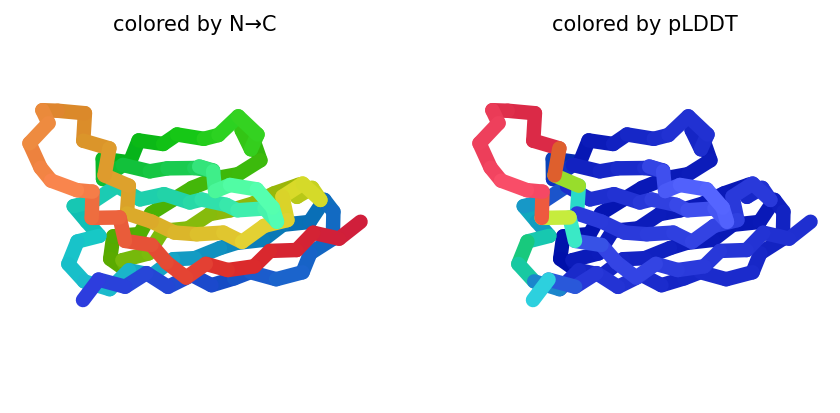

2026-03-06 12:48:03,706 deepfold_v1_model_2_seed_002 recycle=0 pLDDT=86.9
2026-03-06 12:48:12,738 deepfold_v1_model_2_seed_002 recycle=1 pLDDT=87.2 tol=0.257
2026-03-06 12:48:21,840 deepfold_v1_model_2_seed_002 recycle=2 pLDDT=87.4 tol=0.247
2026-03-06 12:48:31,026 deepfold_v1_model_2_seed_002 recycle=3 pLDDT=87.6 tol=0.153
2026-03-06 12:48:40,212 deepfold_v1_model_2_seed_002 recycle=4 pLDDT=87.7 tol=0.21
2026-03-06 12:48:49,432 deepfold_v1_model_2_seed_002 recycle=5 pLDDT=87.8 tol=0.173
2026-03-06 12:48:58,633 deepfold_v1_model_2_seed_002 recycle=6 pLDDT=87.6 tol=0.287
2026-03-06 12:48:58,634 deepfold_v1_model_2_seed_002 took 63.9s (6 recycles)


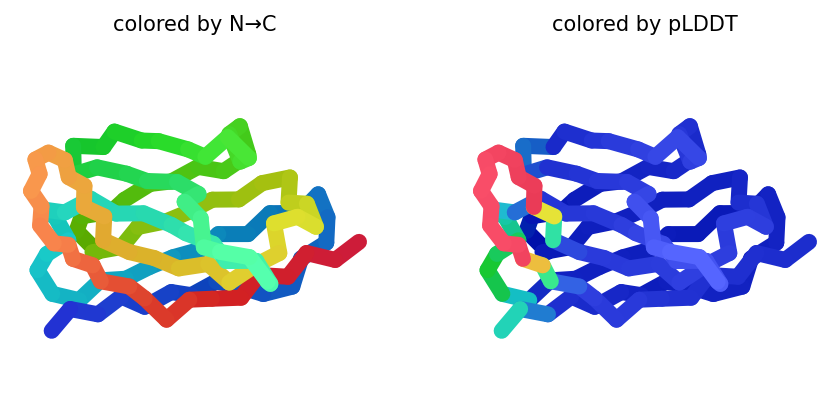

2026-03-06 12:49:07,938 deepfold_v1_model_3_seed_002 recycle=0 pLDDT=86.1
2026-03-06 12:49:17,088 deepfold_v1_model_3_seed_002 recycle=1 pLDDT=87.6 tol=0.669
2026-03-06 12:49:26,228 deepfold_v1_model_3_seed_002 recycle=2 pLDDT=87.8 tol=0.302
2026-03-06 12:49:35,378 deepfold_v1_model_3_seed_002 recycle=3 pLDDT=87.6 tol=0.486
2026-03-06 12:49:44,525 deepfold_v1_model_3_seed_002 recycle=4 pLDDT=87.6 tol=0.49
2026-03-06 12:49:53,662 deepfold_v1_model_3_seed_002 recycle=5 pLDDT=87.8 tol=0.193
2026-03-06 12:50:02,803 deepfold_v1_model_3_seed_002 recycle=6 pLDDT=87.7 tol=0.365
2026-03-06 12:50:02,804 deepfold_v1_model_3_seed_002 took 64.0s (6 recycles)


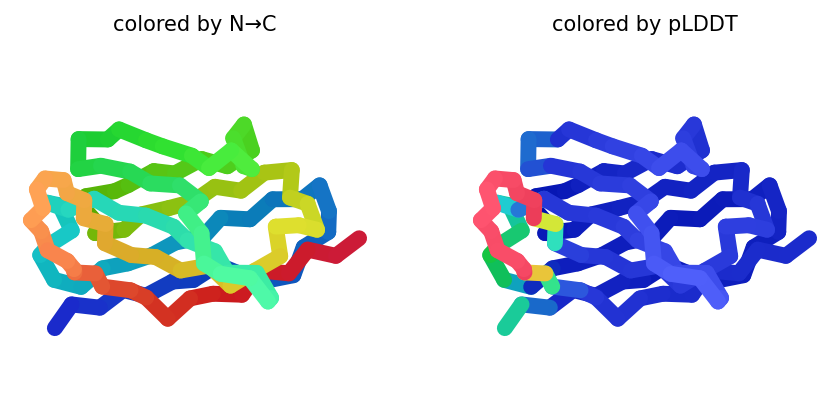

2026-03-06 12:50:12,067 deepfold_v1_model_4_seed_002 recycle=0 pLDDT=86
2026-03-06 12:50:21,211 deepfold_v1_model_4_seed_002 recycle=1 pLDDT=86.8 tol=0.535
2026-03-06 12:50:30,331 deepfold_v1_model_4_seed_002 recycle=2 pLDDT=87 tol=0.318
2026-03-06 12:50:39,463 deepfold_v1_model_4_seed_002 recycle=3 pLDDT=86.6 tol=0.313
2026-03-06 12:50:48,581 deepfold_v1_model_4_seed_002 recycle=4 pLDDT=86.6 tol=0.271
2026-03-06 12:50:57,701 deepfold_v1_model_4_seed_002 recycle=5 pLDDT=86.8 tol=0.239
2026-03-06 12:51:06,821 deepfold_v1_model_4_seed_002 recycle=6 pLDDT=86.8 tol=0.328
2026-03-06 12:51:06,822 deepfold_v1_model_4_seed_002 took 63.9s (6 recycles)


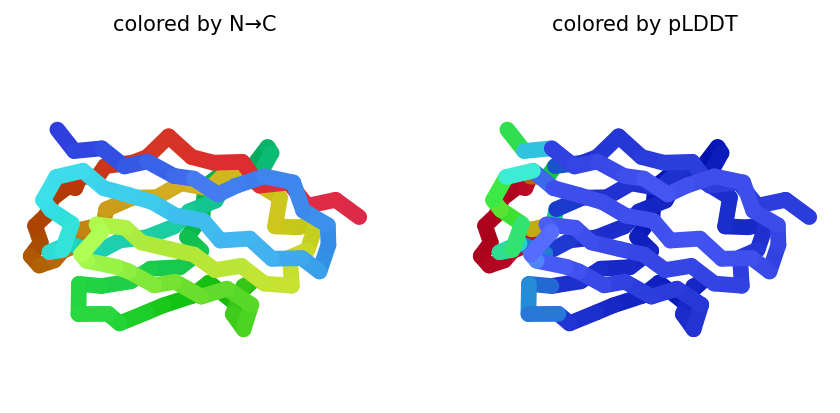

2026-03-06 12:51:16,071 deepfold_v1_model_5_seed_002 recycle=0 pLDDT=85.7
2026-03-06 12:51:25,223 deepfold_v1_model_5_seed_002 recycle=1 pLDDT=86.9 tol=0.709
2026-03-06 12:51:34,368 deepfold_v1_model_5_seed_002 recycle=2 pLDDT=87 tol=0.265
2026-03-06 12:51:43,509 deepfold_v1_model_5_seed_002 recycle=3 pLDDT=87 tol=0.614
2026-03-06 12:51:52,645 deepfold_v1_model_5_seed_002 recycle=4 pLDDT=86.8 tol=0.547
2026-03-06 12:52:01,782 deepfold_v1_model_5_seed_002 recycle=5 pLDDT=86.9 tol=0.383
2026-03-06 12:52:10,915 deepfold_v1_model_5_seed_002 recycle=6 pLDDT=87 tol=0.379
2026-03-06 12:52:10,916 deepfold_v1_model_5_seed_002 took 64.0s (6 recycles)


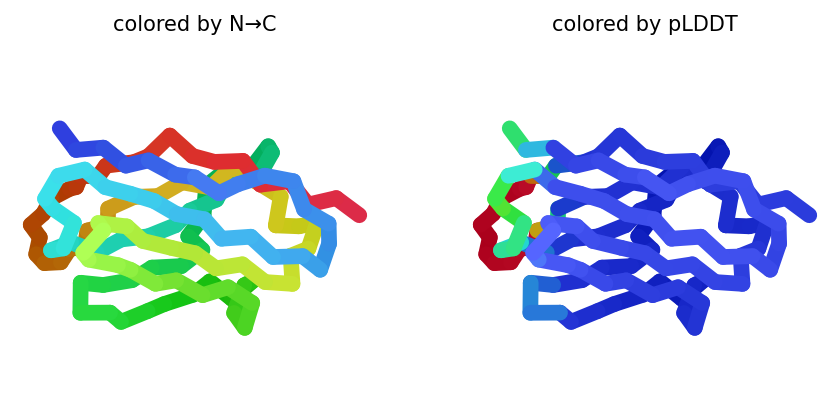

2026-03-06 12:52:27,131 deepfold_v1_model_1_seed_003 recycle=0 pLDDT=88.4
2026-03-06 12:52:36,342 deepfold_v1_model_1_seed_003 recycle=1 pLDDT=88.8 tol=0.518
2026-03-06 12:52:45,578 deepfold_v1_model_1_seed_003 recycle=2 pLDDT=88.8 tol=0.325
2026-03-06 12:52:54,834 deepfold_v1_model_1_seed_003 recycle=3 pLDDT=89.1 tol=0.449
2026-03-06 12:53:03,982 deepfold_v1_model_1_seed_003 recycle=4 pLDDT=89.1 tol=0.279
2026-03-06 12:53:13,040 deepfold_v1_model_1_seed_003 recycle=5 pLDDT=88.8 tol=0.192
2026-03-06 12:53:22,056 deepfold_v1_model_1_seed_003 recycle=6 pLDDT=89.1 tol=0.144
2026-03-06 12:53:22,057 deepfold_v1_model_1_seed_003 took 64.0s (6 recycles)


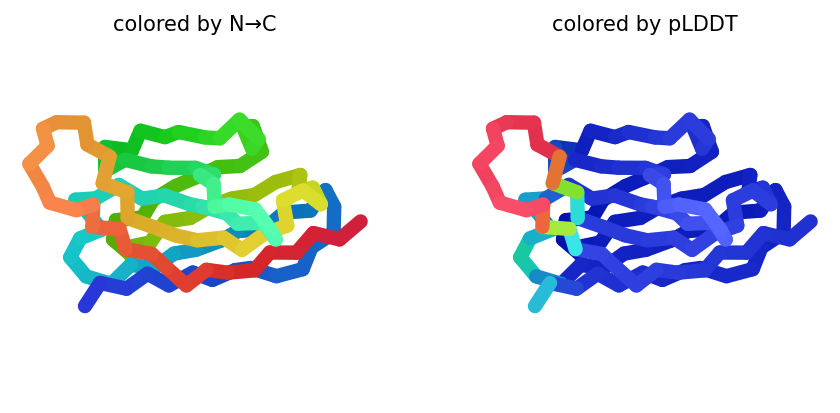

2026-03-06 12:53:31,167 deepfold_v1_model_2_seed_003 recycle=0 pLDDT=87.1
2026-03-06 12:53:40,245 deepfold_v1_model_2_seed_003 recycle=1 pLDDT=87.4 tol=0.423
2026-03-06 12:53:49,409 deepfold_v1_model_2_seed_003 recycle=2 pLDDT=87.5 tol=0.318
2026-03-06 12:53:58,638 deepfold_v1_model_2_seed_003 recycle=3 pLDDT=87.8 tol=0.232
2026-03-06 12:54:07,851 deepfold_v1_model_2_seed_003 recycle=4 pLDDT=87.8 tol=0.171
2026-03-06 12:54:16,997 deepfold_v1_model_2_seed_003 recycle=5 pLDDT=87.5 tol=0.155
2026-03-06 12:54:26,119 deepfold_v1_model_2_seed_003 recycle=6 pLDDT=87.8 tol=0.157
2026-03-06 12:54:26,120 deepfold_v1_model_2_seed_003 took 64.0s (6 recycles)


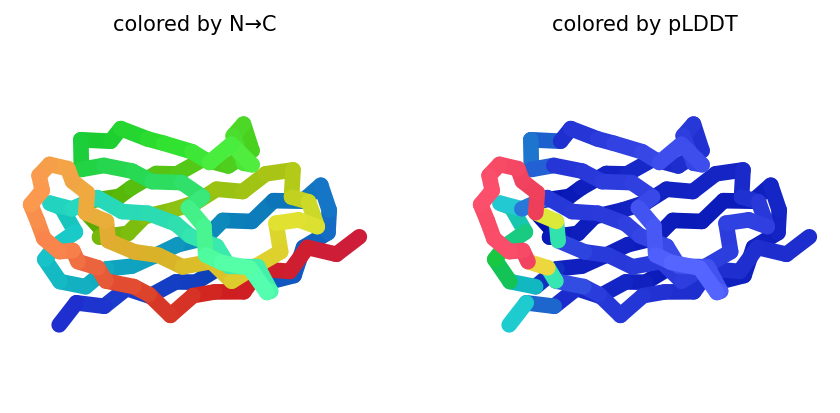

2026-03-06 12:54:35,411 deepfold_v1_model_3_seed_003 recycle=0 pLDDT=87.1
2026-03-06 12:54:44,564 deepfold_v1_model_3_seed_003 recycle=1 pLDDT=86.9 tol=0.507
2026-03-06 12:54:53,692 deepfold_v1_model_3_seed_003 recycle=2 pLDDT=87.5 tol=0.463
2026-03-06 12:55:02,841 deepfold_v1_model_3_seed_003 recycle=3 pLDDT=87.7 tol=0.561
2026-03-06 12:55:11,980 deepfold_v1_model_3_seed_003 recycle=4 pLDDT=87.6 tol=0.241
2026-03-06 12:55:21,119 deepfold_v1_model_3_seed_003 recycle=5 pLDDT=87.4 tol=0.181
2026-03-06 12:55:30,260 deepfold_v1_model_3_seed_003 recycle=6 pLDDT=87.8 tol=0.198
2026-03-06 12:55:30,261 deepfold_v1_model_3_seed_003 took 64.0s (6 recycles)


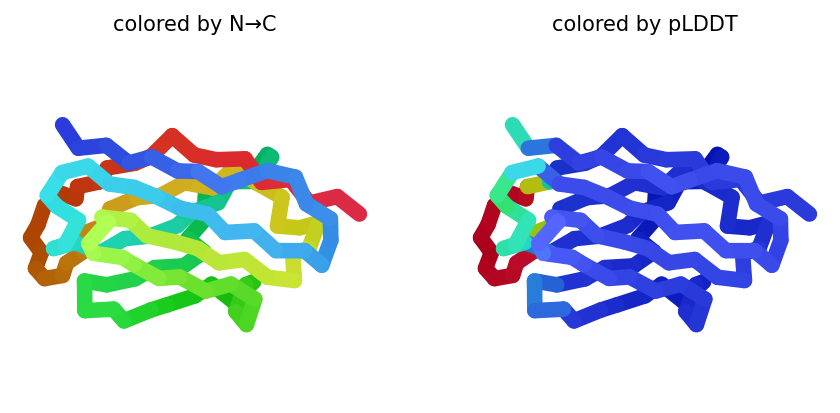

2026-03-06 12:55:39,512 deepfold_v1_model_4_seed_003 recycle=0 pLDDT=86.3
2026-03-06 12:55:48,654 deepfold_v1_model_4_seed_003 recycle=1 pLDDT=86.5 tol=0.451
2026-03-06 12:55:57,781 deepfold_v1_model_4_seed_003 recycle=2 pLDDT=87 tol=0.299
2026-03-06 12:56:06,901 deepfold_v1_model_4_seed_003 recycle=3 pLDDT=86.8 tol=0.48
2026-03-06 12:56:16,039 deepfold_v1_model_4_seed_003 recycle=4 pLDDT=86.6 tol=0.276
2026-03-06 12:56:25,157 deepfold_v1_model_4_seed_003 recycle=5 pLDDT=86.8 tol=0.228
2026-03-06 12:56:34,296 deepfold_v1_model_4_seed_003 recycle=6 pLDDT=86.8 tol=0.261
2026-03-06 12:56:34,297 deepfold_v1_model_4_seed_003 took 63.9s (6 recycles)


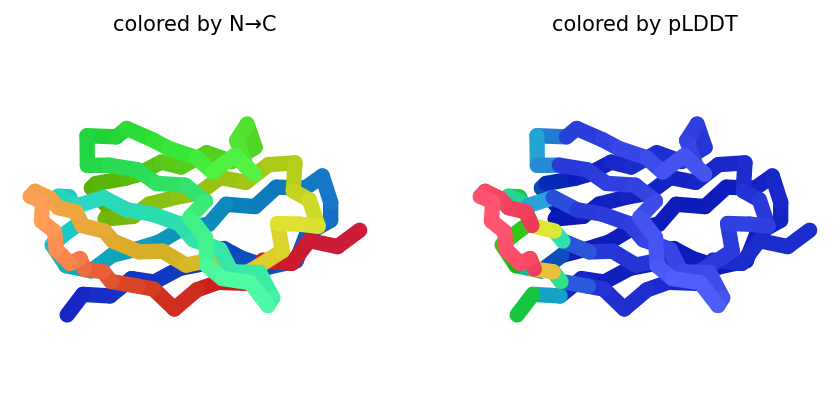

2026-03-06 12:56:43,516 deepfold_v1_model_5_seed_003 recycle=0 pLDDT=86.3
2026-03-06 12:56:52,668 deepfold_v1_model_5_seed_003 recycle=1 pLDDT=86.6 tol=0.354
2026-03-06 12:57:01,826 deepfold_v1_model_5_seed_003 recycle=2 pLDDT=86.9 tol=0.331
2026-03-06 12:57:10,970 deepfold_v1_model_5_seed_003 recycle=3 pLDDT=87.1 tol=0.563
2026-03-06 12:57:20,122 deepfold_v1_model_5_seed_003 recycle=4 pLDDT=86.7 tol=0.217
2026-03-06 12:57:29,255 deepfold_v1_model_5_seed_003 recycle=5 pLDDT=86.6 tol=0.192
2026-03-06 12:57:38,397 deepfold_v1_model_5_seed_003 recycle=6 pLDDT=86.9 tol=0.305
2026-03-06 12:57:38,397 deepfold_v1_model_5_seed_003 took 64.0s (6 recycles)


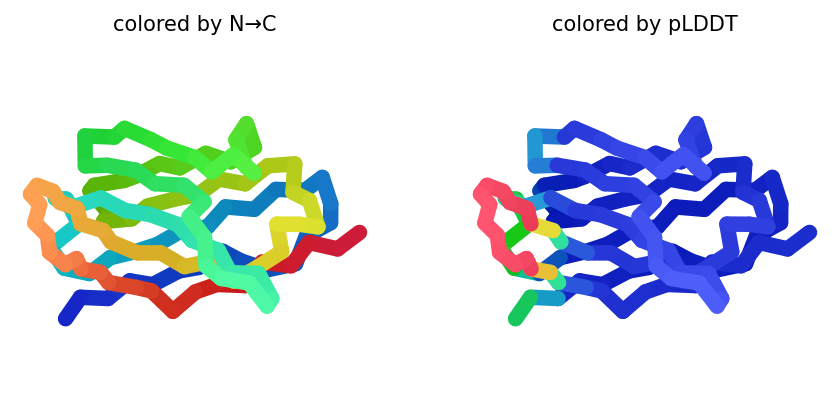

2026-03-06 12:57:38,508 reranking models by 'plddt' metric
2026-03-06 12:57:51,364 Relaxation took 12.9s
2026-03-06 12:57:51,364 rank_001_deepfold_v1_model_1_seed_003 pLDDT=89.1
2026-03-06 12:57:55,328 Relaxation took 4.0s
2026-03-06 12:57:55,328 rank_002_deepfold_v1_model_1_seed_000 pLDDT=89
2026-03-06 12:57:58,821 Relaxation took 3.5s
2026-03-06 12:57:58,821 rank_003_deepfold_v1_model_1_seed_001 pLDDT=89
2026-03-06 12:58:02,372 Relaxation took 3.5s
2026-03-06 12:58:02,372 rank_004_deepfold_v1_model_1_seed_002 pLDDT=88.9
2026-03-06 12:58:11,535 Relaxation took 9.2s
2026-03-06 12:58:11,535 rank_005_deepfold_v1_model_2_seed_003 pLDDT=87.8
2026-03-06 12:58:11,536 rank_006_deepfold_v1_model_3_seed_003 pLDDT=87.8
2026-03-06 12:58:11,536 rank_007_deepfold_v1_model_2_seed_000 pLDDT=87.8
2026-03-06 12:58:11,536 rank_008_deepfold_v1_model_3_seed_002 pLDDT=87.7
2026-03-06 12:58:11,536 rank_009_deepfold_v1_model_2_seed_001 pLDDT=87.7
2026-03-06 12:58:11,536 rank_010_deepfold_v1_model_2_seed_002 

0

In [5]:
#@title Run Prediction
display_images = True #@param {type:"boolean"}

import sys
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2

import os
import numpy as np
try:
  K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
  K80_chk = "0"
  pass
if "1" in K80_chk:
  print("WARNING: found GPU Tesla K80: limited to total length < 1000")
  if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
    del os.environ["TF_FORCE_UNIFIED_MEMORY"]
  if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
    del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

from colabfold.colabfold import plot_protein
from pathlib import Path
import matplotlib.pyplot as plt

# For some reason we need that to get pdbfixer to import
if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
    sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

def input_features_callback(input_features):
  if display_images:
    plot_msa_v2(input_features)
    plt.show()
    plt.close()

def prediction_callback(protein_obj, length,
                        prediction_result, input_features, mode):
  model_name, relaxed = mode
  if not relaxed:
    if display_images:
      fig = plot_protein(protein_obj, Ls=length, dpi=150)
      plt.show()
      plt.close()

result_dir = jobname
log_filename = os.path.join(jobname,"log.txt")
setup_logging(Path(log_filename))

queries, is_complex = get_queries(queries_path)
model_type = set_model_type(is_complex, model_type)

if "multimer" in model_type and max_msa is not None:
  use_cluster_profile = False
else:
  use_cluster_profile = True

download_alphafold_params(model_type, Path("."))
results = run(
    queries=queries,
    result_dir=result_dir,
    use_templates=use_templates,
    custom_template_path=custom_template_path,
    num_relax=num_relax,
    msa_mode=msa_mode,
    model_type=model_type,
    num_models=5,
    num_recycles=num_recycles,
    relax_max_iterations=relax_max_iterations,
    recycle_early_stop_tolerance=recycle_early_stop_tolerance,
    num_seeds=num_seeds,
    use_dropout=use_dropout,
    model_order=[1,2,3,4,5],
    is_complex=is_complex,
    data_dir=Path("."),
    keep_existing_results=False,
    rank_by="auto",
    pair_mode=pair_mode,
    pairing_strategy=pairing_strategy,
    stop_at_score=float(100),
    prediction_callback=prediction_callback,
    dpi=dpi,
    zip_results=False,
    save_all=save_all,
    max_msa=max_msa,
    use_cluster_profile=use_cluster_profile,
    input_features_callback=input_features_callback,
    save_recycles=save_recycles,
    user_agent="colabfold/google-colab-main",
    calc_extra_ptm=calc_extra_ptm,
)
results_zip = f"{jobname}.result.zip"
os.system(f"zip -r {results_zip} {jobname}")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

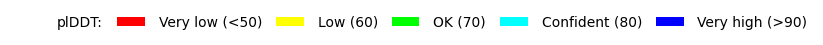

In [6]:
#@title Display 3D structure {run: "auto"}
import py3Dmol
import glob
import matplotlib.pyplot as plt
from colabfold.colabfold import plot_plddt_legend
from colabfold.colabfold import pymol_color_list, alphabet_list
rank_num = 1 #@param ["1", "2", "3", "4", "5"] {type:"raw"}
color = "lDDT" #@param ["chain", "lDDT", "rainbow"]
show_sidechains = True #@param {type:"boolean"}
show_mainchains = True #@param {type:"boolean"}

tag = results["rank"][0][rank_num - 1]
jobname_prefix = ".custom" if msa_mode == "custom" else ""
pdb_filename = f"{jobname}/{jobname}{jobname_prefix}_unrelaxed_{tag}.pdb"
pdb_file = glob.glob(pdb_filename)

def show_pdb(rank_num=1, show_sidechains=False, show_mainchains=False, color="lDDT"):
  model_name = f"rank_{rank_num}"
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',)
  view.addModel(open(pdb_file[0],'r').read(),'pdb')

  if color == "lDDT":
    view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':50,'max':90}}})
  elif color == "rainbow":
    view.setStyle({'cartoon': {'color':'spectrum'}})
  elif color == "chain":
    chains = len(queries[0][1]) + 1 if is_complex else 1
    for n,chain,color in zip(range(chains),alphabet_list,pymol_color_list):
       view.setStyle({'chain':chain},{'cartoon': {'color':color}})

  if show_sidechains:
    BB = ['C','O','N']
    view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                        {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
  if show_mainchains:
    BB = ['C','O','N','CA']
    view.addStyle({'atom':BB},{'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

  view.zoomTo()
  return view

show_pdb(rank_num, show_sidechains, show_mainchains, color).show()
if color == "lDDT":
  plot_plddt_legend().show()


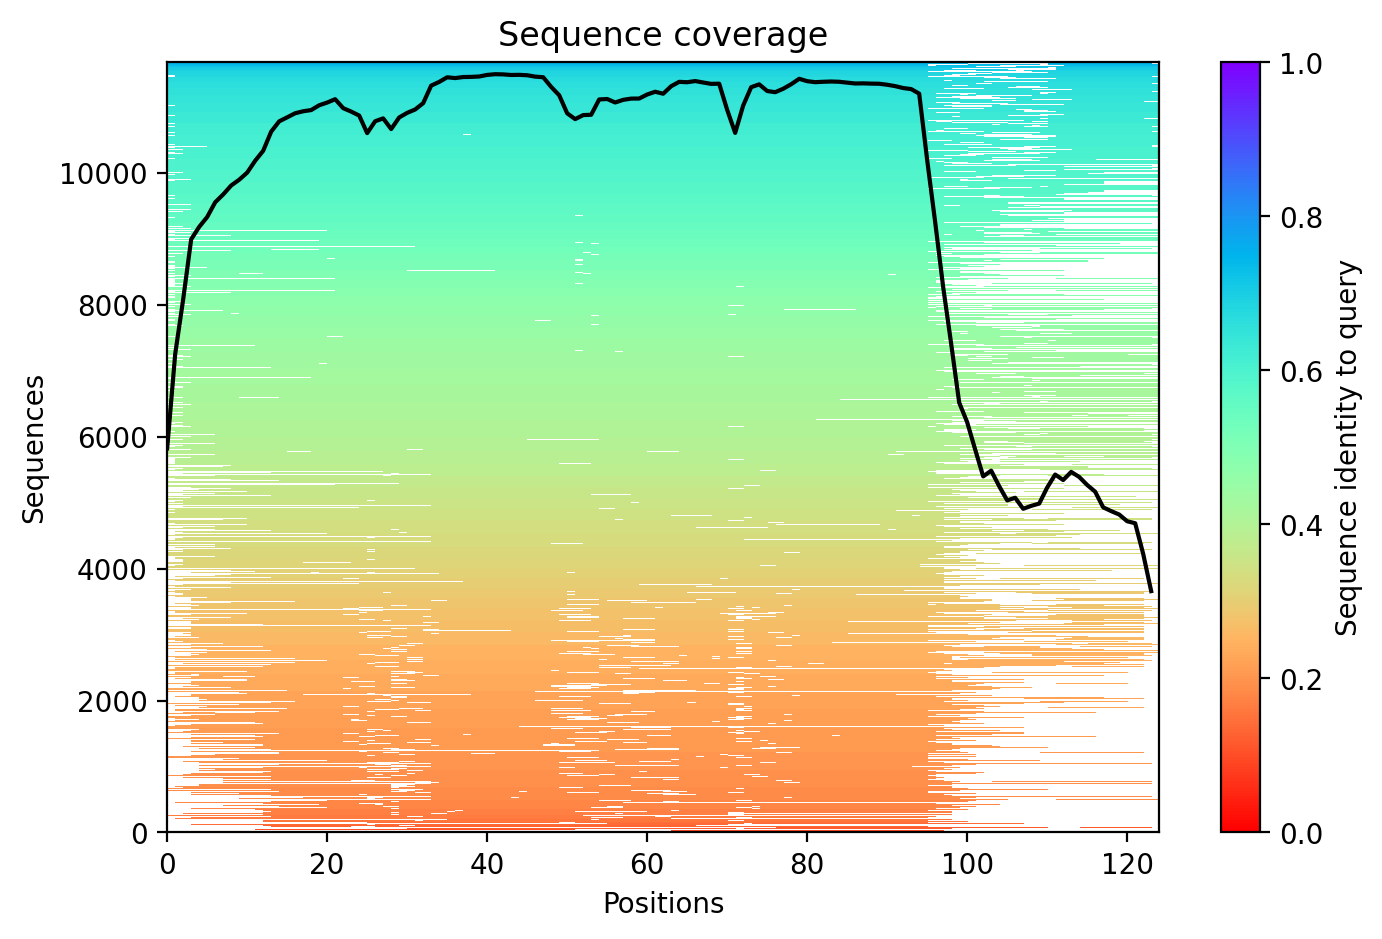
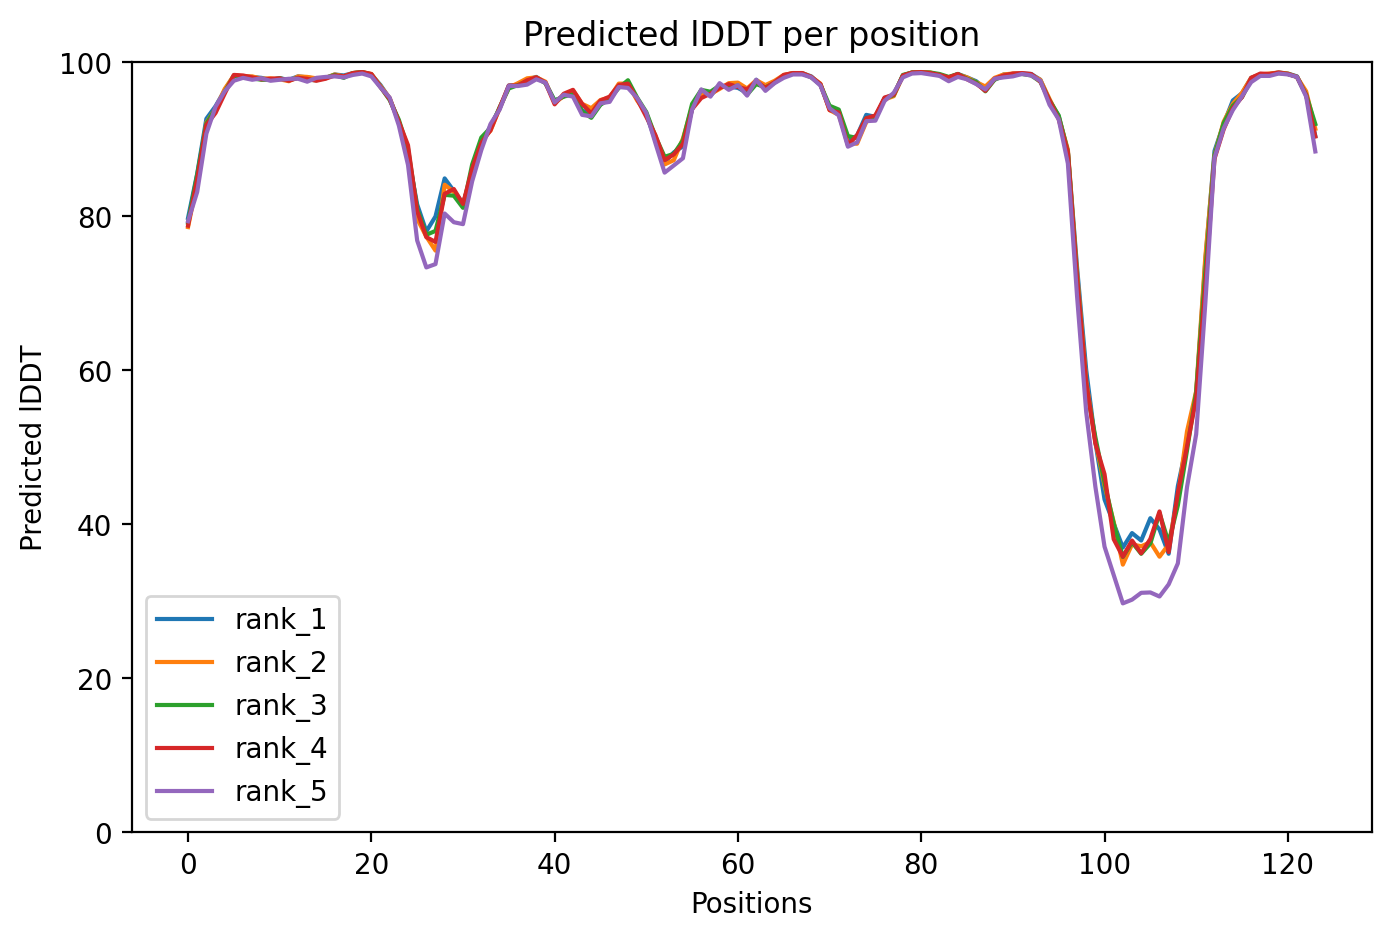

In [7]:
#@title Plots {run: "auto"}
from IPython.display import display, HTML
import base64
from html import escape

# see: https://stackoverflow.com/a/53688522
def image_to_data_url(filename):
  ext = filename.split('.')[-1]
  prefix = f'data:image/{ext};base64,'
  with open(filename, 'rb') as f:
    img = f.read()
  return prefix + base64.b64encode(img).decode('utf-8')

pae = ""
pae_file = os.path.join(jobname,f"{jobname}{jobname_prefix}_pae.png")
if os.path.isfile(pae_file):
    pae = image_to_data_url(pae_file)
cov = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_coverage.png"))
plddt = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_plddt.png"))
display(HTML(f"""
<style>
  img {{
    float:left;
  }}
  .full {{
    max-width:100%;
  }}
  .half {{
    max-width:50%;
  }}
  @media (max-width:640px) {{
    .half {{
      max-width:100%;
    }}
  }}
</style>
<div style="max-width:90%; padding:2em;">
  <h1>Plots for {escape(jobname)}</h1>
  { '<!--' if pae == '' else '' }<img src="{pae}" class="full" />{ '-->' if pae == '' else '' }
  <img src="{cov}" class="half" />
  <img src="{plddt}" class="half" />
</div>
"""))

In [8]:
#@title Package and download results
#@markdown If you are having issues downloading the result archive, try disabling your adblocker and run this cell again. If that fails click on the little folder icon to the left, navigate to file: `jobname.result.zip`, right-click and select \"Download\" (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).

if msa_mode == "custom":
  print("Don't forget to cite your custom MSA generation method.")

files.download(f"{jobname}.result.zip")

if save_to_google_drive == True and drive:
  uploaded = drive.CreateFile({'title': f"{jobname}.result.zip"})
  uploaded.SetContentFile(f"{jobname}.result.zip")
  uploaded.Upload()
  print(f"Uploaded {jobname}.result.zip to Google Drive with ID {uploaded.get('id')}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Instructions <a name="Instructions"></a>
For detailed instructions, tips and tricks, see recently published paper at [Nature Protocols](https://www.nature.com/articles/s41596-024-01060-5)

**Quick start**
1. Paste your protein sequence(s) in the input field.
2. Press "Runtime" -> "Run all".
3. The pipeline consists of 5 steps. The currently running step is indicated by a circle with a stop sign next to it.

**Result zip file contents**

1. PDB formatted structures sorted by avg. pLDDT and complexes are sorted by pTMscore. (unrelaxed and relaxed if `use_amber` is enabled).
2. Plots of the model quality.
3. Plots of the MSA coverage.
4. Parameter log file.
5. A3M formatted input MSA.
6. A `predicted_aligned_error_v1.json` using [AlphaFold-DB's format](https://alphafold.ebi.ac.uk/faq#faq-7) and a `scores.json` for each model which contains an array (list of lists) for PAE, a list with the average pLDDT and the pTMscore.
7. BibTeX file with citations for all used tools and databases.

At the end of the job a download modal box will pop up with a `jobname.result.zip` file. Additionally, if the `save_to_google_drive` option was selected, the `jobname.result.zip` will be uploaded to your Google Drive.

**MSA generation for complexes**

For the complex prediction we use unpaired and paired MSAs. Unpaired MSA is generated the same way as for the protein structures prediction by searching the UniRef100 and environmental sequences three iterations each.

The paired MSA is generated by searching the UniRef100 database and pairing the best hits sharing the same NCBI taxonomic identifier (=species or sub-species). We only pair sequences if all of the query sequences are present for the respective taxonomic identifier.

**Using a custom MSA as input**

To predict the structure with a custom MSA (A3M formatted): (1) Change the `msa_mode`: to "custom", (2) Wait for an upload box to appear at the end of the "MSA options ..." box. Upload your A3M. The first fasta entry of the A3M must be the query sequence without gaps.

It is also possilbe to provide custom MSAs for complex predictions. Read more about the format [here](https://github.com/sokrypton/ColabFold/issues/76).

As an alternative for MSA generation the [HHblits Toolkit server](https://toolkit.tuebingen.mpg.de/tools/hhblits) can be used. After submitting your query, click "Query Template MSA" -> "Download Full A3M". Download the A3M file and upload it in this notebook.

**PDB100** <a name="pdb100"></a>

As of 23/06/08, we have transitioned from using the PDB70 to a 100% clustered PDB, the PDB100. The construction methodology of PDB100 differs from that of PDB70.

The PDB70 was constructed by running each PDB70 representative sequence through [HHblits](https://github.com/soedinglab/hh-suite) against the [Uniclust30](https://uniclust.mmseqs.com/). On the other hand, the PDB100 is built by searching each PDB100 representative structure with [Foldseek](https://github.com/steineggerlab/foldseek) against the [AlphaFold Database](https://alphafold.ebi.ac.uk).

To maintain compatibility with older Notebook versions and local installations, the generated files and API responses will continue to be named "PDB70", even though we're now using the PDB100.

**Using custom templates** <a name="custom_templates"></a>

To predict the structure with a custom template (PDB or mmCIF formatted): (1) change the `template_mode` to "custom" in the execute cell and (2) wait for an upload box to appear at the end of the "Input Protein" box. Select and upload your templates (multiple choices are possible).

* Templates must follow the four letter PDB naming with lower case letters.

* Templates in mmCIF format must contain `_entity_poly_seq`. An error is thrown if this field is not present. The field `_pdbx_audit_revision_history.revision_date` is automatically generated if it is not present.

* Templates in PDB format are automatically converted to the mmCIF format. `_entity_poly_seq` and `_pdbx_audit_revision_history.revision_date` are automatically generated.

If you encounter problems, please report them to this [issue](https://github.com/sokrypton/ColabFold/issues/177).

**Comparison to the full AlphaFold2 and AlphaFold2 Colab**

This notebook replaces the homology detection and MSA pairing of AlphaFold2 with MMseqs2. For a comparison against the [AlphaFold2 Colab](https://colab.research.google.com/github/deepmind/alphafold/blob/main/notebooks/AlphaFold.ipynb) and the full [AlphaFold2](https://github.com/deepmind/alphafold) system read our [paper](https://www.nature.com/articles/s41592-022-01488-1).

**Troubleshooting**
* Check that the runtime type is set to GPU at "Runtime" -> "Change runtime type".
* Try to restart the session "Runtime" -> "Factory reset runtime".
* Check your input sequence.

**Known issues**
* Google Colab assigns different types of GPUs with varying amount of memory. Some might not have enough memory to predict the structure for a long sequence.
* Your browser can block the pop-up for downloading the result file. You can choose the `save_to_google_drive` option to upload to Google Drive instead or manually download the result file: Click on the little folder icon to the left, navigate to file: `jobname.result.zip`, right-click and select \"Download\" (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).

**Limitations**
* Computing resources: Our MMseqs2 API can handle ~20-50k requests per day.
* MSAs: MMseqs2 is very precise and sensitive but might find less hits compared to HHblits/HMMer searched against BFD or MGnify.
* We recommend to additionally use the full [AlphaFold2 pipeline](https://github.com/deepmind/alphafold).

**Description of the plots**
*   **Number of sequences per position** - We want to see at least 30 sequences per position, for best performance, ideally 100 sequences.
*   **Predicted lDDT per position** - model confidence (out of 100) at each position. The higher the better.
*   **Predicted Alignment Error** - For homooligomers, this could be a useful metric to assess how confident the model is about the interface. The lower the better.

**Bugs**
- If you encounter any bugs, please report the issue to https://github.com/sokrypton/ColabFold/issues

**License**

The source code of ColabFold is licensed under [MIT](https://raw.githubusercontent.com/sokrypton/ColabFold/main/LICENSE). Additionally, this notebook uses the AlphaFold2 source code and its parameters licensed under [Apache 2.0](https://raw.githubusercontent.com/deepmind/alphafold/main/LICENSE) and [CC BY 4.0](https://creativecommons.org/licenses/by-sa/4.0/) respectively. Read more about the AlphaFold license [here](https://github.com/deepmind/alphafold).

**Acknowledgments**
- We thank the AlphaFold team for developing an excellent model and open sourcing the software.

- [KOBIC](https://kobic.re.kr) and [Söding Lab](https://www.mpinat.mpg.de/soeding) for providing the computational resources for the MMseqs2 MSA server.

- Richard Evans for helping to benchmark the ColabFold's Alphafold-multimer support.

- [David Koes](https://github.com/dkoes) for his awesome [py3Dmol](https://3dmol.csb.pitt.edu/) plugin, without whom these notebooks would be quite boring!

- Do-Yoon Kim for creating the ColabFold logo.

- A colab by Sergey Ovchinnikov ([@sokrypton](https://twitter.com/sokrypton)), Milot Mirdita ([@milot_mirdita](https://twitter.com/milot_mirdita)) and Martin Steinegger ([@thesteinegger](https://twitter.com/thesteinegger)).
